# Chapter 33 — Gradient Descent With One Parameter

## Learning goals

Chapter 31 introduced parameters, and Chapter 32 used derivatives to describe how parameter changes affect loss.

This chapter combines those ideas into gradient descent, a method that repeatedly updates parameters to reduce loss.

By the end of this chapter, you should be able to:

1. Explain one-parameter gradient descent in plain language.
2. Compute a prediction and squared error loss.
3. Compute and numerically check the gradient with respect to a weight.
4. Update a weight using a learning rate and gradient.
5. Train a one-parameter model automatically.
6. Read and plot a step-by-step training history.
7. Compare learning rates that are too small, useful, at the stability boundary, and too large.
8. Explain why unstable updates can make training explode.
9. Connect one-parameter training to larger models.

## The training problem

We train the same toy model used in the previous two chapters:

```python
prediction = weight * input_number
```

The model has one learnable parameter: `weight`.

We use input `5` and target `10`, so the best weight is `2`.

Unlike manual search, gradient descent will approach that value through repeated updates.

## Terms used in this chapter

- A **parameter** is a number changed during training.
- A **prediction** is the model output.
- A **target** is the desired output.
- A **loss** measures prediction error with one number.
- A **gradient** is the derivative of loss with respect to a parameter.
- A **learning rate** controls the size of a parameter update.
- A **training step** computes a prediction, loss, gradient, and update once.
- **Gradient descent** repeatedly moves parameters opposite their gradients to reduce loss.
- **Convergence** means the parameter and loss approach stable values.
- **Divergence** means updates move away from a solution.
- **Exploding training** is rapid growth in parameters, gradients, or loss caused by unstable updates.

With one parameter, the gradient is one number.

## Prediction and loss

First define the input, target, model, and squared error loss.

Separate functions keep each part of a training step visible.

In [1]:
input_number = 5.0
target_number = 10.0


def predict_with_weight(input_number: float, weight: float) -> float:
    return weight * input_number


def squared_error_loss(prediction: float, target_number: float) -> float:
    error = prediction - target_number
    return error**2


starting_weight = 1.0
starting_prediction = predict_with_weight(input_number, starting_weight)
starting_loss = squared_error_loss(starting_prediction, target_number)

print("Input:", input_number)
print("Target:", target_number)
print("Starting weight:", starting_weight)
print("Starting prediction:", starting_prediction)
print("Starting loss:", starting_loss)

Input: 5.0
Target: 10.0
Starting weight: 1.0
Starting prediction: 5.0
Starting loss: 25.0


The starting prediction is `5`, so its error is `-5` and its squared error loss is `25`.

Training must change the weight so the prediction moves toward `10`.

## Derive the gradient

For this model,

```text
prediction = weight × input
loss = (prediction - target)²
```

the derivative of loss with respect to weight is:

```text
gradient = 2 × (prediction - target) × input
```

The factor `2 × (prediction - target)` comes from differentiating the square.

The final factor `input` accounts for how prediction changes when weight changes.

This use of linked derivatives is the chain rule, which later automatic-differentiation tools apply for us.

In [2]:
def gradient_of_loss_with_respect_to_weight(
    input_number: float,
    target_number: float,
    weight: float,
) -> float:
    prediction = predict_with_weight(input_number, weight)
    return 2 * (prediction - target_number) * input_number


starting_gradient = gradient_of_loss_with_respect_to_weight(
    input_number,
    target_number,
    starting_weight,
)

print("Gradient at weight 1:", starting_gradient)

Gradient at weight 1: -50.0


At weight `1`, the gradient is `-50`.

The negative sign says that a small increase in weight lowers loss.

The magnitude describes local sensitivity, not a complete update by itself.

## Check the gradient numerically

An algebra mistake in a gradient can send training in the wrong direction.

Compare the exact formula with the central finite-difference estimate from Chapter 32.

In [3]:
def loss_for_weight(weight: float) -> float:
    prediction = predict_with_weight(input_number, weight)
    return squared_error_loss(prediction, target_number)


weight_to_check = 1.0
small_change = 0.0001

numerical_gradient = (
    loss_for_weight(weight_to_check + small_change)
    - loss_for_weight(weight_to_check - small_change)
) / (2 * small_change)

exact_gradient = gradient_of_loss_with_respect_to_weight(
    input_number,
    target_number,
    weight_to_check,
)

print("Numerical gradient:", numerical_gradient)
print("Exact gradient:", exact_gradient)
print("Absolute difference:", abs(numerical_gradient - exact_gradient))

assert abs(numerical_gradient - exact_gradient) < 1e-8

Numerical gradient: -49.99999999997229
Exact gradient: -50.0
Absolute difference: 2.7711166694643907e-11


The values agree to floating-point precision.

This check supports the formula, while the exact formula is much cheaper than nudging every parameter during training.

## Take one gradient descent step

For loss minimization, the update rule is:

```python
updated_weight = weight - learning_rate * gradient
```

The gradient points toward increasing loss locally, so the negative sign moves in the opposite direction.

The learning rate scales that move.

In [4]:
weight = 1.0
learning_rate = 0.01

prediction = predict_with_weight(input_number, weight)
loss = squared_error_loss(prediction, target_number)
gradient = gradient_of_loss_with_respect_to_weight(
    input_number,
    target_number,
    weight,
)
updated_weight = weight - learning_rate * gradient

updated_prediction = predict_with_weight(input_number, updated_weight)
updated_loss = squared_error_loss(updated_prediction, target_number)

print("Weight before update:", weight)
print("Gradient:", gradient)
print("Learning rate:", learning_rate)
print("Weight after update:", updated_weight)
print("Loss before update:", loss)
print("Loss after update:", updated_loss)

assert updated_loss < loss

Weight before update: 1.0
Gradient: -50.0
Learning rate: 0.01
Weight after update: 1.5
Loss before update: 25.0
Loss after update: 6.25


The update moves the weight from `1.0` to `1.5` and lowers loss from `25` to `6.25`.

Gradient descent repeats this procedure instead of stopping after one useful step.

## Train repeatedly and store history

The helper below records values before each update and also returns the final weight.

The last recorded `weight` produced the last recorded loss, while `updated_weight` is the value after that step.

In [5]:
def train_one_parameter_model(
    input_number: float,
    target_number: float,
    initial_weight: float,
    learning_rate: float,
    number_of_steps: int,
) -> tuple[list[dict[str, float]], float]:
    if learning_rate <= 0:
        raise ValueError("learning_rate must be positive.")

    if number_of_steps < 1:
        raise ValueError("number_of_steps must be at least 1.")

    weight = initial_weight
    history = []

    for step in range(number_of_steps):
        prediction = predict_with_weight(input_number, weight)
        loss = squared_error_loss(prediction, target_number)
        gradient = gradient_of_loss_with_respect_to_weight(
            input_number,
            target_number,
            weight,
        )
        updated_weight = weight - learning_rate * gradient

        history.append(
            {
                "step": step,
                "weight": weight,
                "prediction": prediction,
                "loss": loss,
                "gradient": gradient,
                "updated_weight": updated_weight,
            }
        )
        weight = updated_weight

    return history, weight

Use a learning rate of `0.01` for 12 steps and print every update.

In [6]:
def print_training_history(history: list[dict[str, float]]) -> None:
    print("step |   weight | prediction |       loss |   gradient | updated weight")
    print("-" * 79)

    for row in history:
        print(
            f"{int(row['step']):>4} | "
            f"{row['weight']:>8.6f} | "
            f"{row['prediction']:>10.6f} | "
            f"{row['loss']:>10.6f} | "
            f"{row['gradient']:>10.6f} | "
            f"{row['updated_weight']:>14.6f}"
        )


good_history, trained_weight = train_one_parameter_model(
    input_number=5.0,
    target_number=10.0,
    initial_weight=1.0,
    learning_rate=0.01,
    number_of_steps=12,
)

print_training_history(good_history)
print()
print("Final weight after all updates:", trained_weight)
print("Final prediction:", predict_with_weight(5.0, trained_weight))

step |   weight | prediction |       loss |   gradient | updated weight
-------------------------------------------------------------------------------
   0 | 1.000000 |   5.000000 |  25.000000 | -50.000000 |       1.500000
   1 | 1.500000 |   7.500000 |   6.250000 | -25.000000 |       1.750000
   2 | 1.750000 |   8.750000 |   1.562500 | -12.500000 |       1.875000
   3 | 1.875000 |   9.375000 |   0.390625 |  -6.250000 |       1.937500
   4 | 1.937500 |   9.687500 |   0.097656 |  -3.125000 |       1.968750
   5 | 1.968750 |   9.843750 |   0.024414 |  -1.562500 |       1.984375
   6 | 1.984375 |   9.921875 |   0.006104 |  -0.781250 |       1.992188
   7 | 1.992188 |   9.960938 |   0.001526 |  -0.390625 |       1.996094
   8 | 1.996094 |   9.980469 |   0.000381 |  -0.195312 |       1.998047
   9 | 1.998047 |   9.990234 |   0.000095 |  -0.097656 |       1.999023
  10 | 1.999023 |   9.995117 |   0.000024 |  -0.048828 |       1.999512
  11 | 1.999512 |   9.997559 |   0.000006 |  -0.024414 |

Each step halves the remaining distance between the weight and `2`.

The loss becomes one quarter of its previous value because squared error squares that distance.

## Plot the training trajectory

One figure combines three views of the same run: loss, parameter value, and prediction.

The dashed lines show the optimal weight and target prediction.

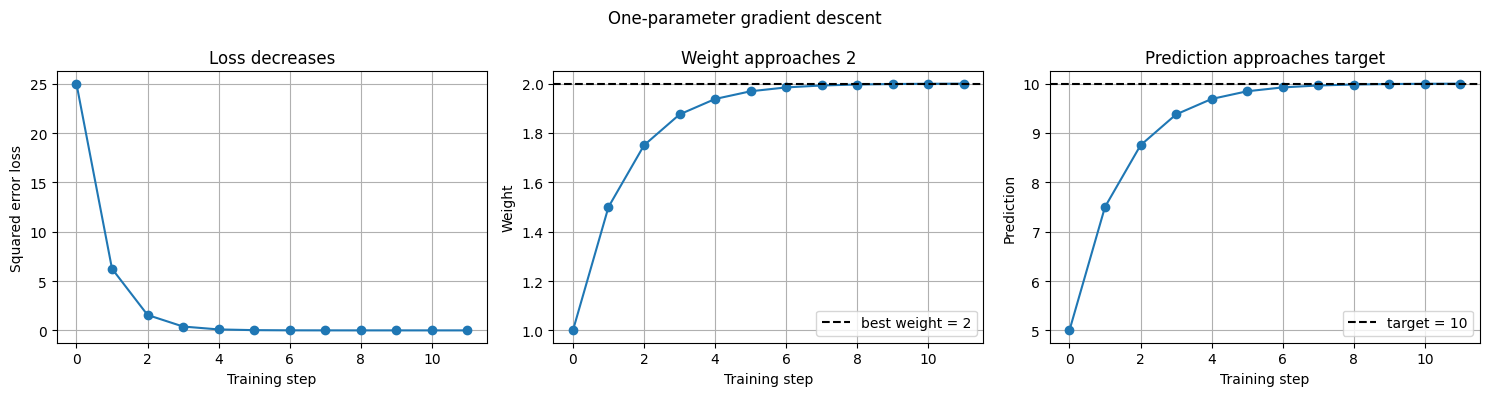

In [7]:
import matplotlib.pyplot as plt

steps = [int(row["step"]) for row in good_history]
losses = [row["loss"] for row in good_history]
weights = [row["weight"] for row in good_history]
predictions = [row["prediction"] for row in good_history]

figure, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(steps, losses, marker="o")
axes[0].set_title("Loss decreases")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Squared error loss")
axes[0].grid(True)

axes[1].plot(steps, weights, marker="o")
axes[1].axhline(2.0, linestyle="--", color="black", label="best weight = 2")
axes[1].set_title("Weight approaches 2")
axes[1].set_xlabel("Training step")
axes[1].set_ylabel("Weight")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(steps, predictions, marker="o")
axes[2].axhline(10.0, linestyle="--", color="black", label="target = 10")
axes[2].set_title("Prediction approaches target")
axes[2].set_xlabel("Training step")
axes[2].set_ylabel("Prediction")
axes[2].legend()
axes[2].grid(True)

figure.suptitle("One-parameter gradient descent")
figure.tight_layout()
plt.show()

The parameter approaches `2`, its prediction approaches `10`, and loss approaches `0`.

## Why the learning rate matters

For this quadratic loss, we can describe every update exactly.

Let `weight error = weight - 2`.

The gradient is `50 × weight error`, so:

```text
new weight error = (1 - 50 × learning rate) × old weight error
```

The multiplier controls the behavior:

- Magnitude below `1` means the error shrinks and training converges.
- Magnitude equal to `1` means the error does not shrink.
- Magnitude above `1` means the error grows and training diverges.

This toy problem converges only when the learning rate is strictly between `0` and `0.04`.

That exact boundary belongs to this loss and input scale; other problems have different safe ranges.

## Compare four learning rates

We compare a rate that is too small, one that works well, the exact stability boundary, and a rate that diverges.

At the boundary, the weight alternates between `1` and `3`, while loss stays at `25`.

In [8]:
learning_rates = {
    "too small: 0.0001": 0.0001,
    "useful: 0.01": 0.01,
    "boundary: 0.04": 0.04,
    "too large: 0.1": 0.1,
}
histories_by_learning_rate = {}

print("learning rate | error multiplier | initial loss | loss after 10 steps")
print("-" * 76)

for label, rate in learning_rates.items():
    rate_history, _ = train_one_parameter_model(
        input_number=5.0,
        target_number=10.0,
        initial_weight=1.0,
        learning_rate=rate,
        number_of_steps=11,
    )
    histories_by_learning_rate[label] = rate_history
    error_multiplier = 1 - 50 * rate
    print(
        f"{rate:>13.4f} | "
        f"{error_multiplier:>16.3f} | "
        f"{rate_history[0]['loss']:>12.6f} | "
        f"{rate_history[-1]['loss']:>19.6f}"
    )

learning rate | error multiplier | initial loss | loss after 10 steps
----------------------------------------------------------------------------
       0.0001 |            0.995 |    25.000000 |           22.615262
       0.0100 |            0.500 |    25.000000 |            0.000024
       0.0400 |           -1.000 |    25.000000 |           25.000000
       0.1000 |           -4.000 |    25.000000 | 27487790694400.000000


The small rate makes progress slowly, and the useful rate reduces loss quickly.

The boundary rate keeps the same loss, while the large rate makes loss grow dramatically.

## Plot stable and unstable training

A logarithmic loss axis compares tiny and enormous values on the same figure.

The second panel shows how the corresponding weights move.

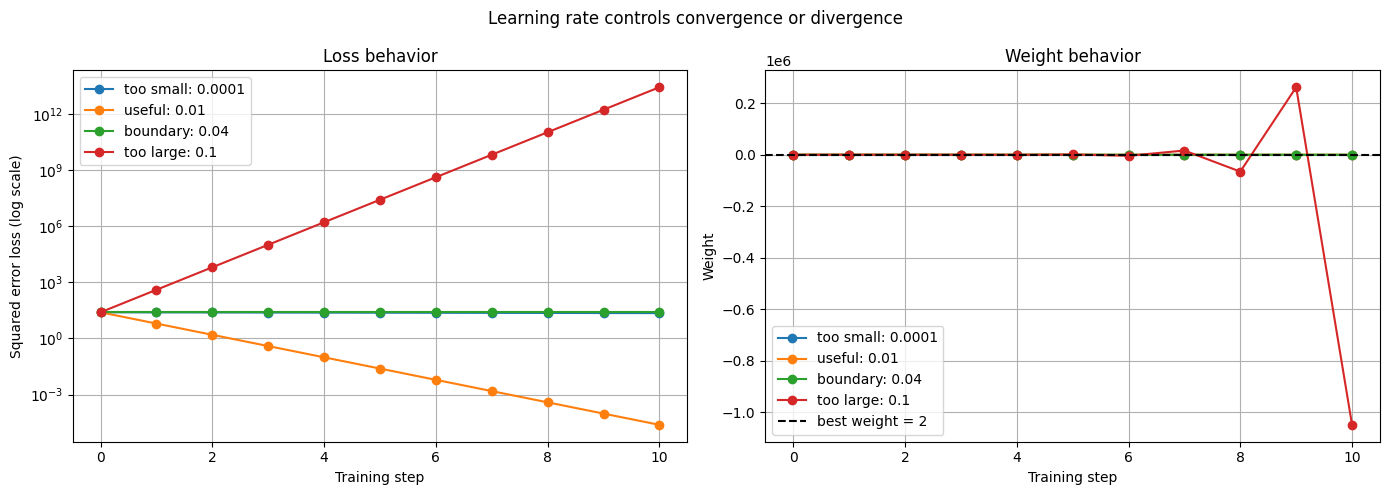

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, rate_history in histories_by_learning_rate.items():
    rate_steps = [int(row["step"]) for row in rate_history]
    rate_losses = [row["loss"] for row in rate_history]
    rate_weights = [row["weight"] for row in rate_history]
    axes[0].plot(rate_steps, rate_losses, marker="o", label=label)
    axes[1].plot(rate_steps, rate_weights, marker="o", label=label)

axes[0].set_yscale("log")
axes[0].set_title("Loss behavior")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Squared error loss (log scale)")
axes[0].legend()
axes[0].grid(True)

axes[1].axhline(2.0, linestyle="--", color="black", label="best weight = 2")
axes[1].set_title("Weight behavior")
axes[1].set_xlabel("Training step")
axes[1].set_ylabel("Weight")
axes[1].legend()
axes[1].grid(True)

figure.suptitle("Learning rate controls convergence or divergence")
figure.tight_layout()
plt.show()

The large-rate trajectory alternates across the optimum with increasing distance.

Larger errors create larger gradients, which create still larger updates, so loss explodes through a positive feedback loop.

## Inspect the exploding steps

Print the large-rate history.

In [10]:
exploding_history = histories_by_learning_rate["too large: 0.1"]
print_training_history(exploding_history)

step |   weight | prediction |       loss |   gradient | updated weight
-------------------------------------------------------------------------------
   0 | 1.000000 |   5.000000 |  25.000000 | -50.000000 |       6.000000
   1 | 6.000000 |  30.000000 | 400.000000 | 200.000000 |     -14.000000
   2 | -14.000000 | -70.000000 | 6400.000000 | -800.000000 |      66.000000
   3 | 66.000000 | 330.000000 | 102400.000000 | 3200.000000 |    -254.000000
   4 | -254.000000 | -1270.000000 | 1638400.000000 | -12800.000000 |    1026.000000
   5 | 1026.000000 | 5130.000000 | 26214400.000000 | 51200.000000 |   -4094.000000
   6 | -4094.000000 | -20470.000000 | 419430400.000000 | -204800.000000 |   16386.000000
   7 | 16386.000000 | 81930.000000 | 6710886400.000000 | 819200.000000 |  -65534.000000
   8 | -65534.000000 | -327670.000000 | 107374182400.000000 | -3276800.000000 |  262146.000000
   9 | 262146.000000 | 1310730.000000 | 1717986918400.000000 | 13107200.000000 | -1048574.000000
  10 | -1048574

The sign alternates because every update crosses the best weight.

The magnitude grows because the learning rate multiplies the weight error by `-4` on every step.

## Gradient direction around the optimum

The gradient sign determines the update direction when the learning rate is positive.

At the optimum, this gradient is zero and the update makes no change.

In [11]:
weights_to_check = [1.0, 1.9, 2.0, 2.1, 3.0]
direction_learning_rate = 0.01

print("weight | prediction | loss | gradient | update direction | updated weight")
print("-" * 83)

for checked_weight in weights_to_check:
    checked_prediction = predict_with_weight(input_number, checked_weight)
    checked_loss = squared_error_loss(checked_prediction, target_number)
    checked_gradient = gradient_of_loss_with_respect_to_weight(
        input_number,
        target_number,
        checked_weight,
    )
    checked_updated_weight = checked_weight - direction_learning_rate * checked_gradient

    if checked_updated_weight > checked_weight:
        update_direction = "up"
    elif checked_updated_weight < checked_weight:
        update_direction = "down"
    else:
        update_direction = "no change"

    print(
        f"{checked_weight:>6.2f} | "
        f"{checked_prediction:>10.4f} | "
        f"{checked_loss:>6.3f} | "
        f"{checked_gradient:>8.3f} | "
        f"{update_direction:>16} | "
        f"{checked_updated_weight:>14.6f}"
    )

weight | prediction | loss | gradient | update direction | updated weight
-----------------------------------------------------------------------------------
  1.00 |     5.0000 | 25.000 |  -50.000 |               up |       1.500000
  1.90 |     9.5000 |  0.250 |   -5.000 |               up |       1.950000
  2.00 |    10.0000 |  0.000 |    0.000 |        no change |       2.000000
  2.10 |    10.5000 |  0.250 |    5.000 |             down |       2.050000
  3.00 |    15.0000 | 25.000 |   50.000 |             down |       2.500000


Below `2`, the gradient is negative and the update raises the weight.

Above `2`, the gradient is positive and the update lowers the weight.

Near `2`, the error and gradient are small, so a fixed learning rate naturally produces smaller updates.

## Start farther from the solution

For this bowl-shaped loss, the useful learning rate also converges from a poor starting weight.

This is not a guarantee for every model because real loss surfaces can be much more complicated.

In [12]:
bad_start_history, bad_start_final_weight = train_one_parameter_model(
    input_number=5.0,
    target_number=10.0,
    initial_weight=-3.0,
    learning_rate=0.01,
    number_of_steps=15,
)

print("Initial weight:", bad_start_history[0]["weight"])
print("Initial loss:", bad_start_history[0]["loss"])
print("Final weight:", bad_start_final_weight)
print("Final loss before the last update:", bad_start_history[-1]["loss"])

assert bad_start_history[-1]["loss"] < bad_start_history[0]["loss"]

Initial weight: -3.0
Initial loss: 625.0
Final weight: 1.999847412109375
Final loss before the last update: 2.3283064365386963e-06


## What gradient descent does—and does not do

Gradient descent follows a numerical procedure:

1. Compute a prediction.
2. Compute loss.
3. Compute the gradient.
4. Update the parameter.
5. Repeat.

It does not understand that `5 × 2 = 10` in a human sense.

It changes a number according to how that number affects the chosen loss.

This chapter uses one example and one parameter, while real language models use batches, many parameter arrays, and more complicated losses.

## From one parameter to many

For one parameter, the gradient is one scalar.

For many parameters, every learned number has a partial derivative measuring its local effect on loss.

The complete collection is called the gradient and has the same structure as the parameters.

The conceptual update remains:

```text
new parameter = old parameter - learning rate × parameter gradient
```

Automatic differentiation will eventually compute those gradients efficiently.

## A clean one-parameter training pipeline

This final cell trains the model and verifies the result after all updates.

In [13]:
pipeline_history, pipeline_final_weight = train_one_parameter_model(
    input_number=5.0,
    target_number=10.0,
    initial_weight=1.0,
    learning_rate=0.01,
    number_of_steps=20,
)

initial_record = pipeline_history[0]
final_record = pipeline_history[-1]
pipeline_final_prediction = predict_with_weight(5.0, pipeline_final_weight)
pipeline_final_loss = squared_error_loss(pipeline_final_prediction, 10.0)

assert final_record["loss"] < initial_record["loss"]
assert abs(pipeline_final_weight - 2.0) < 1e-5
assert pipeline_final_loss < 1e-8

print("Initial weight:", initial_record["weight"])
print("Initial loss:", initial_record["loss"])
print("Final weight after 20 updates:", pipeline_final_weight)
print("Final prediction:", pipeline_final_prediction)
print("Final loss:", pipeline_final_loss)
print("All training checks passed.")

Initial weight: 1.0
Initial loss: 25.0
Final weight after 20 updates: 1.9999990463256836
Final prediction: 9.999995231628418
Final loss: 2.2737367544323206e-11
All training checks passed.


## What not to do

- Do not forget the negative sign when minimizing loss.
- Do not confuse the loss with its gradient.
- Do not assume a gradient supplies a safe step size.
- Do not assume every positive learning rate converges.
- Do not interpret one overshoot as exploding training; explosion means distance and loss keep growing.
- Do not report the last pre-update weight as the final post-update weight.
- Do not assume this quadratic captures every difficulty of neural-network training.

## Gotchas

- The gradient gives local sensitivity and direction.
- The learning rate determines how much of that gradient becomes an update.
- A small learning rate can converge too slowly.
- A large learning rate can cross the optimum repeatedly and diverge.
- The exact stable range depends on loss curvature and input scale.
- A zero gradient means no first-order update, but it does not always prove a global minimum.
- Stored history should distinguish values before and after an update.

## Takeaways

Gradient descent repeatedly computes a prediction, loss, gradient, and parameter update.

For this toy model:

```python
prediction = weight * input_number
loss = (prediction - target_number) ** 2
gradient = 2 * (prediction - target_number) * input_number
updated_weight = weight - learning_rate * gradient
```

A useful learning rate moves the weight toward `2` and loss toward `0`.

A rate that is too small wastes steps, while a rate that is too large creates unstable, exploding updates.

The gradient and learning rate must be understood together.

## What comes next

The next chapter trains one parameter from several input-target pairs.

Using average loss over a dataset will show how one update can summarize evidence from multiple examples instead of fitting only one pair.